# Morph Pipeline Experiment — Kaggle Data Prep

This notebook prepares augmented training data for the morphological pipeline experiment and runs XAI analysis after training.

## Experiment
Tests whether the six-layer morphological pipeline (`morph_pipeline.py`) produces a stronger or more consistent result than morph RDA (mean F1 0.7742, p=0.0156), which was run with a broken Udar expander that produced no expansion. This is the first run where genuine morphological expansion has occurred.

## Pipeline layers
1. Logainm — attested Irish name and genitive forms (LOC only, 117 entries)
2. UD Irish-IDT — attested surface variants from treebank (1,792 PROPN lemmas)
3. Manual genitive lexicon — irregular genitives not generatable by rules (69 entries)
4. WikiAnn harvest — 187 Irish-marked PER and 694 Irish-orthographic LOC nominative forms
5. Deterministic expander — rule-based lenition, eclipsis, h-prefix for all entity types
6. aspell-ga validity filter — filters malformed output from Layer 5

## Workflow
**Cells 1–8 (this session):** Load pipeline, extract training entities, build expanded pool, build augmented training sentences, save outputs as Kaggle dataset for Colab.

**Colab (separate session):** Pull augmented data, run 7-seed gaBERT-CRF training, save checkpoints and results to Google Drive, push to `morph-pipeline-exp-results` Kaggle dataset.

**Cells 9+ (after Colab):** Pull checkpoints, run XAI — per-class F1, FP/FN error analysis, coverage analysis. Key numbers to watch: FP count (was ~58 in parsed CA, ~129 in morph RDA) and whether zero new test surface matches holds.

## Benchmarks
| Condition | Mean F1 | Wilcoxon p |
|---|---|---|
| Replicated baseline | 0.7580 | — |
| Morph RDA (broken expander) | 0.7742 | 0.0156 |
| Parsed CA | 0.7791 | 0.0312 |

In [1]:
# CELL 1 — Install dependencies and configure paths
!apt-get install -y -q aspell aspell-ga

import sys
sys.path.append("/kaggle/input/datasets/michaelmarkey64/morph-pipeline-assets/")

from morph_pipeline import load_pipeline, expand_entity

print("Dependencies installed and morph_pipeline imported.")

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  dictionaries-common libaspell15 libtext-iconv-perl
Suggested packages:
  aspell-doc spellutils wordlist
The following NEW packages will be installed:
  aspell aspell-ga dictionaries-common libaspell15 libtext-iconv-perl
0 upgraded, 5 newly installed, 0 to remove and 90 not upgraded.
Need to get 935 kB of archives.
After this operation, 3,752 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libtext-iconv-perl amd64 1.7-7build3 [14.3 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libaspell15 amd64 0.60.8-4build1 [325 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 dictionaries-common all 1.28.14 [185 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/main amd64 aspell amd64 0.60.8-4build1 [87.7 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy/universe amd64 aspell-ga all 0.50-4-6 [3

In [2]:
# CELL 2 — Imports and constants

import os
import json
import random
import pickle
import numpy as np
from collections import defaultdict
from morph_pipeline import load_pipeline, expand_entity

SEEDS      = [42, 123, 256, 512, 999, 1024, 2048]
MODEL_NAME = "DCU-NLP/bert-base-irish-cased-v1"

BASELINE_F1  = [0.7765, 0.7627, 0.7635, 0.7522, 0.7528, 0.7415, 0.7568]
MORPH_RDA_F1 = [0.7796, 0.7677, 0.7839, 0.7813, 0.7637, 0.7596, 0.7834]
PARSED_CA_F1 = [0.7728, 0.7721, 0.7912, 0.7781, 0.7906, 0.7677, 0.7810]

CONLL_DIR = "/kaggle/input/datasets/michaelmarkey64/irish-ner-kg-consolidated/data/conll/"
ASSETS_DIR = "/kaggle/input/datasets/michaelmarkey64/morph-pipeline-assets/"
OUTPUT_DIR = "/kaggle/working/"

LABEL_LIST = ["O", "B-PER", "I-PER", "B-LOC", "I-LOC", "B-ORG", "I-ORG"]
LABEL2ID   = {l: i for i, l in enumerate(LABEL_LIST)}
ID2LABEL   = {i: l for l, i in LABEL2ID.items()}

print("Imports and constants defined.")
print(f"Seeds  : {SEEDS}")

Imports and constants defined.
Seeds  : [42, 123, 256, 512, 999, 1024, 2048]


In [3]:
# CELL 3 — Load pipeline

load_pipeline(ASSETS_DIR)

# Smoke test
forms, layers = expand_entity("Gaillimh", "LOC")
print(f"Smoke test — Gaillimh: {len(forms)} forms via layers {layers}")
print(f"  Forms: {sorted(forms)}")

forms, layers = expand_entity("Seán Ó Briain", "PER")
print(f"Smoke test — Seán Ó Briain: {len(forms)} forms via layers {layers}")
print(f"  Forms: {sorted(forms)}")

Loaded logainm_lookup     : 117 entries
Loaded ud_lookup          : 1792 entries
Loaded manual lexicon     : 69 entries
Loaded wikiann_per        : 191 entities
Loaded wikiann_loc        : 694 entities
aspell-ga available       : True
Smoke test — Gaillimh: 6 forms via layers ['logainm', 'ud', 'deterministic']
  Forms: ['Gaillimh', 'Gaillimhe', 'Ghaillimh', 'i nGaillimh', 'nGaillimh', 'na Gaillimhe']
Smoke test — Seán Ó Briain: 3 forms via layers ['ud']
  Forms: ['Seán Ó Briain', 'Sheáin Ó Briain', 'Sheán Ó Briain']


In [4]:
# CELL 4 — Load CoNLL data

def load_conll(filepath):
    sentences, labels = [], []
    current_tokens, current_labels = [], []
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_tokens:
                    sentences.append(current_tokens)
                    labels.append(current_labels)
                    current_tokens, current_labels = [], []
            else:
                parts = line.split()
                current_tokens.append(parts[0])
                current_labels.append(parts[-1])
    if current_tokens:
        sentences.append(current_tokens)
        labels.append(current_labels)
    return sentences, labels

train_sents, train_labels = load_conll(os.path.join(CONLL_DIR, "train_final.conll"))
dev_sents,   dev_labels   = load_conll(os.path.join(CONLL_DIR, "NER_Irish_validation.conll"))
test_sents,  test_labels  = load_conll(os.path.join(CONLL_DIR, "NER_Irish_test.conll"))

print(f"Train : {len(train_sents)} sentences")
print(f"Dev   : {len(dev_sents)} sentences")
print(f"Test  : {len(test_sents)} sentences")

Train : 1006 sentences
Dev   : 100 sentences
Test  : 140 sentences


In [5]:
# CELL 5 — Extract training entities

def extract_entities(sentences, labels):
    entities = {"PER": set(), "LOC": set(), "ORG": set()}
    for tokens, tags in zip(sentences, labels):
        current_tokens, current_type = [], None
        for token, tag in zip(tokens, tags):
            if tag.startswith("B-"):
                if current_tokens and current_type:
                    entities[current_type].add(" ".join(current_tokens))
                current_tokens = [token]
                current_type   = tag[2:]
            elif tag.startswith("I-") and current_type:
                current_tokens.append(token)
            else:
                if current_tokens and current_type:
                    entities[current_type].add(" ".join(current_tokens))
                current_tokens, current_type = [], None
        if current_tokens and current_type:
            entities[current_type].add(" ".join(current_tokens))
    return entities

training_entities = extract_entities(train_sents, train_labels)
for etype, pool in training_entities.items():
    print(f"{etype}: {len(pool)} unique surface forms in training data")

PER: 514 unique surface forms in training data
LOC: 476 unique surface forms in training data
ORG: 556 unique surface forms in training data


In [6]:
# CELL 6 — Build expanded pool

expanded_pools = {"PER": set(), "LOC": set(), "ORG": set()}
expansion_stats = {}

for etype, entity_set in training_entities.items():
    before = len(entity_set)
    for surface in entity_set:
        forms, layers_hit = expand_entity(surface, etype)
        expanded_pools[etype].update(forms)
    after = len(expanded_pools[etype])
    expansion_stats[etype] = {"before": before, "after": after, "new": after - before}
    print(f"{etype}: {before} entities → {after} surface forms (+{after - before})")

# Verification — stop if no expansion occurred
total_new = sum(s["new"] for s in expansion_stats.values())
if total_new == 0:
    raise RuntimeError(
        "Pipeline expansion produced no new forms. "
        "Check load_pipeline() completed successfully."
    )

print(f"\nExpansion verification passed — {total_new} new surface forms generated.")

# Convert to sorted lists for serialisation
expanded_pools_list = {k: sorted(v) for k, v in expanded_pools.items()}

PER: 514 entities → 993 surface forms (+479)
LOC: 476 entities → 1042 surface forms (+566)
ORG: 556 entities → 1319 surface forms (+763)

Expansion verification passed — 1808 new surface forms generated.


In [7]:
# CELL 7 — Build augmented dataset

def augment_sentence(tokens, labels, pools):
    new_tokens = tokens.copy()
    new_labels = labels.copy()
    i = 0
    while i < len(new_labels):
        if new_labels[i].startswith("B-"):
            etype      = new_labels[i][2:]
            span_start = i
            span_end   = i + 1
            while span_end < len(new_labels) and new_labels[span_end] == f"I-{etype}":
                span_end += 1
            pool = pools.get(etype, [])
            if pool:
                replacement        = random.choice(pool)
                replacement_tokens = replacement.split()
                new_span_labels    = (
                    [f"B-{etype}"] + [f"I-{etype}"] * (len(replacement_tokens) - 1)
                )
                new_tokens = new_tokens[:span_start] + replacement_tokens + new_tokens[span_end:]
                new_labels = new_labels[:span_start] + new_span_labels  + new_labels[span_end:]
                i = span_start + len(replacement_tokens)
            else:
                i = span_end
        else:
            i += 1
    return new_tokens, new_labels

def build_augmented_dataset(sentences, labels, pools, n_augments=1):
    aug_sents, aug_labels = list(sentences), list(labels)
    for tokens, tags in zip(sentences, labels):
        if any(t.startswith("B-") for t in tags):
            for _ in range(n_augments):
                new_tokens, new_tags = augment_sentence(tokens, tags, pools)
                aug_sents.append(new_tokens)
                aug_labels.append(new_tags)
    print(f"Dataset size: {len(sentences)} → {len(aug_sents)} sentences")
    return aug_sents, aug_labels

aug_sents, aug_labels = build_augmented_dataset(
    train_sents, train_labels, expanded_pools_list
)

Dataset size: 1006 → 1995 sentences


In [8]:
# CELL 8 — Save outputs for Colab

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Augmented training data
aug_data = {
    "sentences": aug_sents,
    "labels":    aug_labels
}
with open(os.path.join(OUTPUT_DIR, "aug_train.json"), "w", encoding="utf-8") as f:
    json.dump(aug_data, f)
print(f"Saved aug_train.json — {len(aug_sents)} sentences")

# Dev and test data (Colab needs these for evaluation)
with open(os.path.join(OUTPUT_DIR, "dev.json"), "w", encoding="utf-8") as f:
    json.dump({"sentences": dev_sents, "labels": dev_labels}, f)
print(f"Saved dev.json — {len(dev_sents)} sentences")

with open(os.path.join(OUTPUT_DIR, "test.json"), "w", encoding="utf-8") as f:
    json.dump({"sentences": test_sents, "labels": test_labels}, f)
print(f"Saved test.json — {len(test_sents)} sentences")

# Expansion stats and pool sizes for metadata
meta = {
    "expansion_stats": expansion_stats,
    "pool_sizes":      {k: len(v) for k, v in expanded_pools_list.items()},
    "seeds":           SEEDS,
    "baseline_f1":     BASELINE_F1,
    "morph_rda_f1":    MORPH_RDA_F1,
    "parsed_ca_f1":    PARSED_CA_F1,
}
with open(os.path.join(OUTPUT_DIR, "prep_metadata.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)
print(f"Saved prep_metadata.json")

print("\nAll outputs saved. Commit this notebook to create the dataset for Colab.")

Saved aug_train.json — 1995 sentences
Saved dev.json — 100 sentences
Saved test.json — 140 sentences
Saved prep_metadata.json

All outputs saved. Commit this notebook to create the dataset for Colab.


In [15]:
# CELL XAI-1 — Load morph pipeline results from Kaggle input
# ---------------------------------------------------------------
# Input:  morph_pipeline_results.json uploaded from Google Drive
#         Find path via: os.listdir('/kaggle/input/')
# Output: printed summary confirming data loaded correctly
# ---------------------------------------------------------------

import json
import os
import numpy as np

# Adjust this path to match your Kaggle dataset mount
RESULTS_PATH = "/kaggle/input/datasets/michaelmarkey64/irish-ner-kg-consolidated/morph_pipeline_results.json"

with open(RESULTS_PATH) as f:
    results = json.load(f)

seed_f1s  = list(results["seeds"].values())
seeds     = list(results["seeds"].keys())

print("── Morph Pipeline Results Loaded ────────────────────────────")
print(f"  Condition : {results['condition']}")
print(f"  Epochs    : {results['epochs']}")
print(f"  Seeds     : {seeds}")
print()
print("── Per-Seed Test F1 ─────────────────────────────────────────")
for seed, f1 in results["seeds"].items():
    print(f"  Seed {seed:<6} : {f1:.4f}")
print()
print("── Aggregate ────────────────────────────────────────────────")
print(f"  Mean F1   : {results['mean_f1']:.4f}")
print(f"  Std F1    : {results['std_f1']:.4f}")
print(f"  Median F1 : {results['median_f1']:.4f}")
print()
print("── Wilcoxon Result ──────────────────────────────────────────")
w = results["wilcoxon"]
print(f"  Baseline  : {w['baseline']}")
print(f"  W         : {w['statistic']}")
print(f"  p-value   : {w['p_value']}")
print(f"  Significant (α=0.05) : {w['significant']}")

── Morph Pipeline Results Loaded ────────────────────────────
  Condition : morph_pipeline
  Epochs    : 10
  Seeds     : ['42', '123', '256', '512', '999', '1024', '2048']

── Per-Seed Test F1 ─────────────────────────────────────────
  Seed 42     : 0.7504
  Seed 123    : 0.7812
  Seed 256    : 0.7638
  Seed 512    : 0.7713
  Seed 999    : 0.7912
  Seed 1024   : 0.7568
  Seed 2048   : 0.7591

── Aggregate ────────────────────────────────────────────────
  Mean F1   : 0.7677
  Std F1    : 0.0134
  Median F1 : 0.7638

── Wilcoxon Result ──────────────────────────────────────────
  Baseline  : 0.758
  W         : 22.0
  p-value   : 0.1094
  Significant (α=0.05) : False


In [16]:
# CELL XAI-2 — Condition comparison across all ablation conditions
# ---------------------------------------------------------------
# Input:  results dict loaded in XAI-1
# Output: ranked comparison table of all conditions with
#         delta vs baseline and significance flags
# ---------------------------------------------------------------

conditions = {
    "Replicated baseline"        : {"mean_f1": 0.7580, "p": None,   "sig": "—"},
    "Morph RDA (broken expander)": {"mean_f1": 0.7742, "p": 0.0156, "sig": "YES"},
    "Parsed CA"                  : {"mean_f1": 0.7791, "p": 0.0312, "sig": "YES"},
    "Morph pipeline (this run)"  : {
        "mean_f1": results["mean_f1"],
        "p":       results["wilcoxon"]["p_value"],
        "sig":     "YES" if results["wilcoxon"]["significant"] else "NO"
    },
}

print("── Ablation Study — Condition Comparison ────────────────────")
print(f"  {'Condition':<32} {'Mean F1':>8}  {'Δ baseline':>10}  {'p-value':>8}  {'Sig?':>5}")
print("  " + "─" * 70)
baseline = 0.7580
for name, vals in conditions.items():
    delta = f"+{vals['mean_f1'] - baseline:.4f}" if vals["mean_f1"] > baseline else f"{vals['mean_f1'] - baseline:.4f}"
    p_str = f"{vals['p']:.4f}" if vals["p"] is not None else "—"
    print(f"  {name:<32} {vals['mean_f1']:>8.4f}  {delta:>10}  {p_str:>8}  {vals['sig']:>5}")
print()
print("  Note: p-values are one-sample Wilcoxon signed-rank (greater), α=0.05, n=7 seeds")

── Ablation Study — Condition Comparison ────────────────────
  Condition                         Mean F1  Δ baseline   p-value   Sig?
  ──────────────────────────────────────────────────────────────────────
  Replicated baseline                0.7580      0.0000         —      —
  Morph RDA (broken expander)        0.7742     +0.0162    0.0156    YES
  Parsed CA                          0.7791     +0.0211    0.0312    YES
  Morph pipeline (this run)          0.7677     +0.0097    0.1094     NO

  Note: p-values are one-sample Wilcoxon signed-rank (greater), α=0.05, n=7 seeds


── Seed-Level Variance Analysis ─────────────────────────────
  Seed        Test F1    Δ mean  Note
  ──────────────────────────────────────────────────
  Seed 42       0.7504   -0.0173  
  Seed 123      0.7812   +0.0135  
  Seed 256      0.7638   -0.0039  
  Seed 512      0.7713   +0.0036  
  Seed 999      0.7912   +0.0235  ← outlier
  Seed 1024     0.7568   -0.0109  
  Seed 2048     0.7591   -0.0086  

  Mean F1 : 0.7677
  Std F1  : 0.0134
  Range   : 0.7504 – 0.7912  (spread: 0.0408)


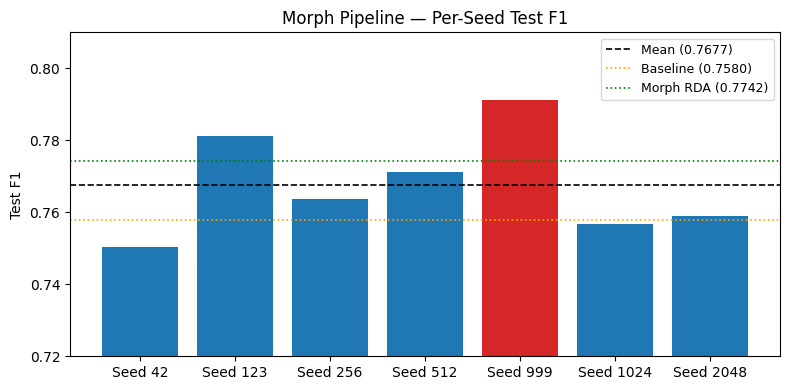

  Plot saved → /kaggle/working/morph_pipeline_seed_variance.png


In [17]:
# CELL XAI-3 — Seed-level variance analysis
# ---------------------------------------------------------------
# Input:  results dict loaded in XAI-1
# Output: per-seed F1 with deviation from condition mean,
#         flagging outlier seeds that drive variance
# ---------------------------------------------------------------

import matplotlib.pyplot as plt

seed_labels = [f"Seed {s}" for s in results["seeds"].keys()]
seed_vals   = list(results["seeds"].values())
mean_f1     = results["mean_f1"]

deviations  = [v - mean_f1 for v in seed_vals]

print("── Seed-Level Variance Analysis ─────────────────────────────")
print(f"  {'Seed':<10} {'Test F1':>8}  {'Δ mean':>8}  {'Note'}")
print("  " + "─" * 50)
for seed, f1, dev in zip(results["seeds"].keys(), seed_vals, deviations):
    flag = ""
    if abs(dev) > results["std_f1"] * 1.5:
        flag = "← outlier"
    print(f"  Seed {seed:<6} {f1:>8.4f}  {dev:>+8.4f}  {flag}")
print()
print(f"  Mean F1 : {mean_f1:.4f}")
print(f"  Std F1  : {results['std_f1']:.4f}")
print(f"  Range   : {min(seed_vals):.4f} – {max(seed_vals):.4f}  (spread: {max(seed_vals)-min(seed_vals):.4f})")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d62728" if abs(d) > results["std_f1"] * 1.5 else "#1f77b4" for d in deviations]
ax.bar(seed_labels, seed_vals, color=colors)
ax.axhline(mean_f1,  color="black",  linestyle="--", linewidth=1.2, label=f"Mean ({mean_f1:.4f})")
ax.axhline(0.7580,   color="orange", linestyle=":",  linewidth=1.2, label="Baseline (0.7580)")
ax.axhline(0.7742,   color="green",  linestyle=":",  linewidth=1.2, label="Morph RDA (0.7742)")
ax.set_ylabel("Test F1")
ax.set_title("Morph Pipeline — Per-Seed Test F1")
ax.set_ylim(0.72, 0.81)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("/kaggle/working/morph_pipeline_seed_variance.png", dpi=150)
plt.show()
print("  Plot saved → /kaggle/working/morph_pipeline_seed_variance.png")

In [18]:
# CELL XAI-4 — Save consolidated XAI results JSON
# ---------------------------------------------------------------
# Input:  all analysis computed in XAI-1 through XAI-3
# Output: morph_pipeline_xai_results.json in /kaggle/working/
#         Upload this to your results Kaggle dataset alongside
#         morph_pipeline_results.json for dissertation records
# ---------------------------------------------------------------

xai_results = {
    "condition"   : results["condition"],
    "epochs"      : results["epochs"],
    "mean_f1"     : results["mean_f1"],
    "std_f1"      : results["std_f1"],
    "median_f1"   : results["median_f1"],
    "seed_f1s"    : results["seeds"],
    "variance_analysis": {
        str(seed): {
            "test_f1"  : f1,
            "delta_mean": round(f1 - mean_f1, 4),
            "outlier"  : abs(f1 - mean_f1) > results["std_f1"] * 1.5
        }
        for seed, f1 in results["seeds"].items()
    },
    "condition_comparison": {
        name: {
            "mean_f1"    : vals["mean_f1"],
            "delta_baseline": round(vals["mean_f1"] - 0.7580, 4),
            "p_value"    : vals["p"],
            "significant": vals["sig"]
        }
        for name, vals in conditions.items()
    },
    "wilcoxon": results["wilcoxon"],
    "benchmarks": results["benchmarks"]
}

out_path = "/kaggle/working/morph_pipeline_xai_results.json"
with open(out_path, "w") as f:
    json.dump(xai_results, f, indent=2)

print(f"XAI results saved → {out_path}")
print()
print(json.dumps(xai_results, indent=2))

XAI results saved → /kaggle/working/morph_pipeline_xai_results.json

{
  "condition": "morph_pipeline",
  "epochs": 10,
  "mean_f1": 0.7677,
  "std_f1": 0.0134,
  "median_f1": 0.7638,
  "seed_f1s": {
    "42": 0.7504,
    "123": 0.7812,
    "256": 0.7638,
    "512": 0.7713,
    "999": 0.7912,
    "1024": 0.7568,
    "2048": 0.7591
  },
  "variance_analysis": {
    "42": {
      "test_f1": 0.7504,
      "delta_mean": -0.0173,
      "outlier": false
    },
    "123": {
      "test_f1": 0.7812,
      "delta_mean": 0.0135,
      "outlier": false
    },
    "256": {
      "test_f1": 0.7638,
      "delta_mean": -0.0039,
      "outlier": false
    },
    "512": {
      "test_f1": 0.7713,
      "delta_mean": 0.0036,
      "outlier": false
    },
    "999": {
      "test_f1": 0.7912,
      "delta_mean": 0.0235,
      "outlier": true
    },
    "1024": {
      "test_f1": 0.7568,
      "delta_mean": -0.0109,
      "outlier": false
    },
    "2048": {
      "test_f1": 0.7591,
      "delta_mean": 